In [1]:
import numpy as np
import pandas as pd

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("Everything works! Ready to build.")

numpy : 2.4.3
pandas: 3.0.1
Everything works! Ready to build.


In [9]:
def spam_traditional(mail):
    """write every rule manually"""
    if "free money" in email:
        return "SPAM"
    if "win a prize" in email:
        return "SPAM"
    if "lottery" in email:
        return "SPAM"
    return "NOT SPAM"

emails = [
    "you won a free money lottery",
    "meeting at 3pm tomorrow",
    "win a prize today"
]

print("=== Traditional Programming ===")
for email in emails:
    print(f"'{email}'")
    print(f"Result: {spam_traditional(email)}")
    print()

# PROBLEM: What about "Fr3e M0ney"?
# You'd update rules forever manually
# you have to do lot of coding patterns and conditions we cant do this forever

=== Traditional Programming ===
'you won a free money lottery'
Result: SPAM

'meeting at 3pm tomorrow'
Result: NOT SPAM

'win a prize today'
Result: SPAM



In [10]:
#ML

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# Training examples with correct answers
emails = [
    "free money win now",         # spam
    "meeting at 3pm",             # not spam
    "you won a prize",            # spam
    "project update required",    # not spam
    "lottery winner selected",    # spam
    "please review the doc",      # not spam
    "free gift claim now",        # spam
    "can we schedule a call",     # not spam
]
labels = [1, 0, 1, 0, 1, 0, 1, 0]
# 1 = spam, 0 = not spam

# Convert text to numbers
# ML only understands numbers not words
# Create an instance of CountVectorizer
# stop_words: removes common, low-information words (e.g., “the”, “is”) from the vocabulary.
vectorizer = CountVectorizer(stop_words="english")

# Fit the vectorizer to the data and transform the data into a document-term matrix
# matrix is set of vectors where each row is a vector (from Math learn lesson)
X = vectorizer.fit_transform(emails)

In [15]:
### Just visualize what happens
# To view the resulting matrix as a dense NumPy array (for small datasets)
print(X.toarray())

# To see the learned vocabulary and the index assigned to each word
print(vectorizer.vocabulary_)

# To get the feature names (words) as an output array
print(vectorizer.get_feature_names_out())

[[0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]]
{'free': 3, 'money': 7, 'win': 15, 'meeting': 6, '3pm': 0, 'won': 17, 'prize': 8, 'project': 9, 'update': 14, 'required': 10, 'lottery': 5, 'winner': 16, 'selected': 13, 'review': 11, 'doc': 2, 'gift': 4, 'claim': 1, 'schedule': 12}
['3pm' 'claim' 'doc' 'free' 'gift' 'lottery' 'meeting' 'money' 'prize'
 'project' 'required' 'review' 'schedule' 'selected' 'update' 'win'
 'winner' 'won']


In [18]:
# Train — model finds patterns itself
model = MultinomialNB()
model.fit(X, labels)
print("Model trained! Zero rules written.\n")

Model trained! Zero rules written.



In [19]:
# Test on emails model never saw
new_emails = [
    "free prize for you",
    "can we schedule a call",
    "win free money now",
    "project deadline tomorrow"
]

X_new      = vectorizer.transform(new_emails)
predictions = model.predict(X_new)

In [23]:
for result,email in zip(predictions,new_emails):
    res = "SPAM" if result==1 else "NOT SPAM"
    print(f"'{email}' is {res} email")

'free prize for you' is SPAM email
'can we schedule a call' is NOT SPAM email
'win free money now' is SPAM email
'project deadline tomorrow' is NOT SPAM email


## Checking my First ML Real model

###  Load data

In [56]:
from sklearn.datasets import load_iris
import pandas as pd

# 150 flowers, 3 species, 4 measurements each
data = load_iris()

In [57]:
df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

In [58]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [59]:
df['species'] = data.target

In [60]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [61]:
df['species_name'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

In [62]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [63]:
print("=== Dataset ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
print(df.head())
print("\n=== Species Count ===")
print(df['species_name'].value_counts())

=== Dataset ===
Rows: 150, Columns: 6

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

=== Species Count ===
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


###  Visualize

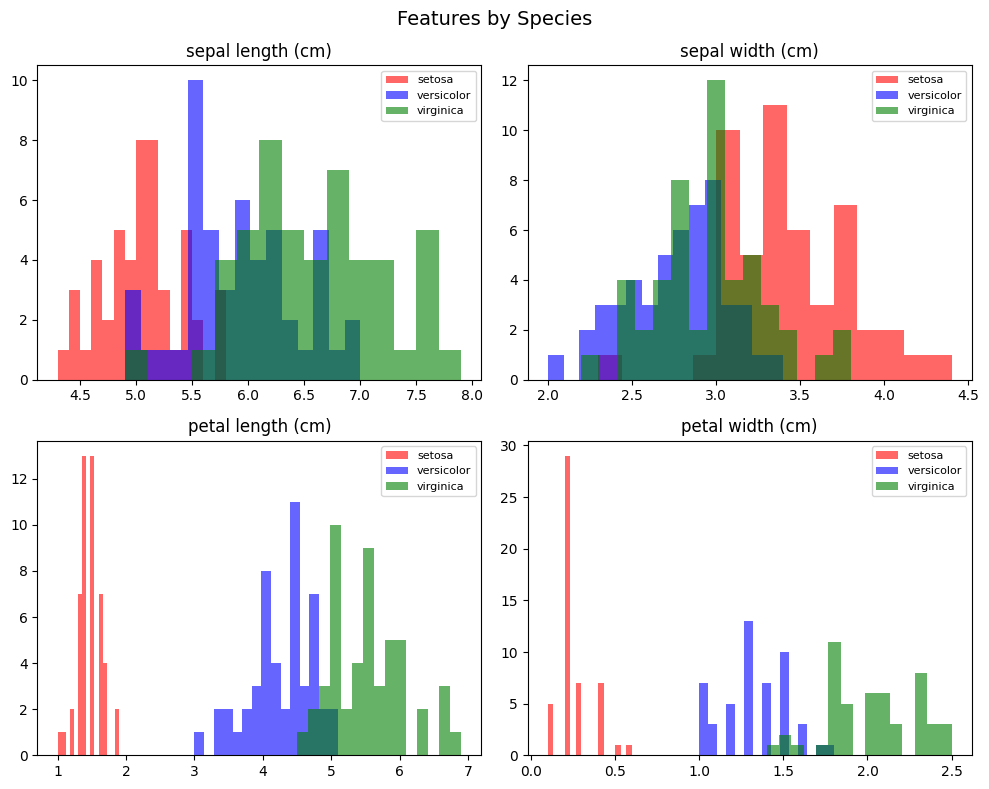

Notice: petal length & width
separate species most clearly
ML will use exactly this pattern


In [64]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
colors  = ['red', 'blue', 'green']
species = data.target_names

for ax, feature in zip(axes.flat, data.feature_names):
    for species_id, color, name in zip([0,1,2], colors, species):
        mask = df['species'] == species_id
        ax.hist(df[mask][feature], alpha=0.6,
                color=color, label=name, bins=15)
    ax.set_title(feature)
    ax.legend(fontsize=8)

plt.suptitle('Features by Species', fontsize=14)
plt.tight_layout()
plt.show()

print("Notice: petal length & width")
print("separate species most clearly")
print("ML will use exactly this pattern")
### From this data we can say that which is base for out categorization
## main purpose of this to get the insight of data

### Split data


In [65]:
from sklearn.model_selection import train_test_split

X = df[data.feature_names]   # what model sees
y = df['species']            # what model predicts

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% for testing
    random_state=42    # same split every run
)

print(f"Training samples: {len(X_train)} (80%)")
print(f"Testing samples:  {len(X_test)}  (20%)")
print("\nRule: Never show test data during training")
print("Like exam — practice questions vs real exam")

Training samples: 120 (80%)
Testing samples:  30  (20%)

Rule: Never show test data during training
Like exam — practice questions vs real exam


In [66]:
X_train



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [67]:
y_train

22     0
15     0
65     1
11     0
42     0
      ..
71     1
106    2
14     0
92     1
102    2
Name: species, Length: 120, dtype: int64

In [68]:
y_train

22     0
15     0
65     1
11     0
42     0
      ..
71     1
106    2
14     0
92     1
102    2
Name: species, Length: 120, dtype: int64

In [69]:
X_test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
73,6.1,2.8,4.7,1.2
18,5.7,3.8,1.7,0.3
118,7.7,2.6,6.9,2.3
78,6.0,2.9,4.5,1.5
76,6.8,2.8,4.8,1.4
31,5.4,3.4,1.5,0.4
64,5.6,2.9,3.6,1.3
141,6.9,3.1,5.1,2.3
68,6.2,2.2,4.5,1.5
82,5.8,2.7,3.9,1.2


In [70]:
y_test

73     1
18     0
118    2
78     1
76     1
31     0
64     1
141    2
68     1
82     1
110    2
12     0
36     0
9      0
19     0
56     1
104    2
69     1
55     1
132    2
29     0
127    2
26     0
128    2
131    2
145    2
108    2
143    2
45     0
30     0
Name: species, dtype: int64

Train Test Split Using Sklearn
The train_test_split() method is used to split our data into train and test sets. 

First, we need to divide our data into features (X) and labels (y). The dataframe gets divided into X_train,X_test , y_train and y_test. X_train and y_train sets are used for training and fitting the model. The X_test and y_test sets are used for testing the model if it's predicting the right outputs/labels. we can explicitly test the size of the train and test sets. It is suggested to keep our train sets larger than the test sets.


Train set: The training dataset is a set of data that was utilized to fit the model. The dataset on which the model is trained. This data is seen and learned by the model.


Test set: The test dataset is a subset of the training dataset that is utilized to give an accurate evaluation of a final model fit.


validation set:  A validation dataset is a sample of data from your model's training set that is used to estimate model performance while tuning the model's hyperparameters.


by default, 25% of our data is test set and 75% data goes into training tests.

### train model

In [71]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc  = model.score(X_test,  y_test)

print("✅ Model trained!\n")
print(f"Training accuracy: {train_acc:.1%}")
print(f"Testing accuracy:  {test_acc:.1%}")

if train_acc - test_acc > 0.1:
    print("\n⚠️ Overfitting — memorized training data")
else:
    print("\n✅ Good — works well on new data")

✅ Model trained!

Training accuracy: 99.2%
Testing accuracy:  100.0%

✅ Good — works well on new data


### Predictions

In [72]:
predictions = model.predict(X_test)
predictions

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [73]:
actual = [ data.target_names[i] for i in y_test]
actual

[np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('virginica'),
 np.str_('virginica'),
 np.str_('virginica'),
 np.str_('virginica'),
 np.str_('setosa'),
 np.str_('setosa')]

In [74]:
predicted = [data.target_names[i] for i in predictions]
predicted

[np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('virginica'),
 np.str_('virginica'),
 np.str_('virginica'),
 np.str_('virginica'),
 np.str_('setosa'),
 np.str_('setosa')]

In [75]:
## creating df
data_ = {"Actual":actual,"predicted":predicted}
results = pd.DataFrame(data_)
results

,Actual,predicted
0,versicolor,versicolor
1,setosa,setosa
2,virginica,virginica
3,versicolor,versicolor
4,versicolor,versicolor
5,setosa,setosa
6,versicolor,versicolor
7,virginica,virginica
8,versicolor,versicolor
9,versicolor,versicolor


In [76]:

results['Correct'] = results['Actual'] == results['predicted']

print("=== Actual vs Predicted ===")
print(results.head(10))
print(f"\nCorrect: {results['Correct'].sum()}/{len(results)}")
print(f"Wrong:   {(~results['Correct']).sum()}/{len(results)}")

=== Actual vs Predicted ===
       Actual   predicted  Correct
0  versicolor  versicolor     True
1      setosa      setosa     True
2   virginica   virginica     True
3  versicolor  versicolor     True
4  versicolor  versicolor     True
5      setosa      setosa     True
6  versicolor  versicolor     True
7   virginica   virginica     True
8  versicolor  versicolor     True
9  versicolor  versicolor     True

Correct: 30/30
Wrong:   0/30


### Confusion matrix

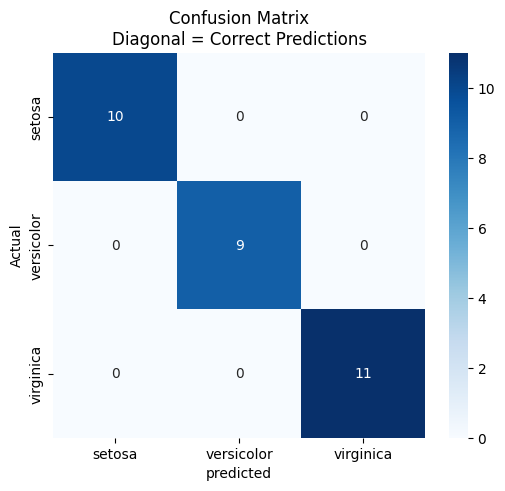

Diagonal = correct predictions
Off diagonal = mistakes


In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title('Confusion Matrix\nDiagonal = Correct Predictions')
plt.ylabel('Actual')
plt.xlabel('predicted')
plt.show()

print("Diagonal = correct predictions")
print("Off diagonal = mistakes")

### Compare models

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'Decision Tree':       DecisionTreeClassifier(max_depth=5),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}

print("=== Model Comparison ===\n")
scores = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    acc     = m.score(X_test, y_test)
    scores[name] = acc
    bar     = "█" * int(acc * 30)
    print(f"{name:25} {bar} {acc:.1%}")

best = max(scores, key=scores.get)
print(f"\n🏆 Best today: {best} ({scores[best]:.1%})")

=== Model Comparison ===

Decision Tree             ██████████████████████████████ 100.0%
Logistic Regression       ██████████████████████████████ 100.0%
Random Forest             ██████████████████████████████ 100.0%
KNN                       ██████████████████████████████ 100.0%

🏆 Best today: Decision Tree (100.0%)
